# Advanced Machine Learning - Final Project
## Anti-Money Laundering (AML) Transaction Classification
**Author:** Asier Larrazabal, Giovanni Pacchetti and Asier Aurre

### 0. Setup and Data Loading
In this section, we import the necessary libraries and load the pre-merged dataset containing transactions, accounts, and laundering patterns.

In [1]:
# Install required libraries if not already present
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn optuna lightgbm xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Define the path to your merged dataset
# Make sure to adjust this path to where your file is located
DATA_PATH = "data/ibm_aml_multiclass_clases.csv" 

print("Loading dataset... (This may take a moment for large files)")
try:
    # Load the dataset. We use low_memory=False to avoid DtypeWarnings 
    # but we will optimize memory immediately after checking the info.
    df = pd.read_csv(DATA_PATH, low_memory=False)
    
    print("\n✅ Dataset loaded successfully!")
    print(f"Shape: {df.shape[0]:,} rows and {df.shape[1]} columns")
    
    print("\n--- Basic Information ---")
    df.info()
    
    display(df.head(5))
    
except FileNotFoundError:
    print(f"❌ Error: Could not find the file at '{DATA_PATH}'. Please check the path.")

Loading dataset... (This may take a moment for large files)

✅ Dataset loaded successfully!
Shape: 31,898,238 rows and 13 columns

--- Basic Information ---
<class 'pandas.DataFrame'>
RangeIndex: 31898238 entries, 0 to 31898237
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           str    
 1   From Bank           int64  
 2   Account             str    
 3   To Bank             int64  
 4   Account.1           str    
 5   Amount Received     float64
 6   Receiving Currency  str    
 7   Amount Paid         float64
 8   Payment Currency    str    
 9   Payment Format      str    
 10  Is Laundering       int64  
 11  pattern_base        str    
 12  target_multi        int64  
dtypes: float64(2), int64(4), str(7)
memory usage: 3.1 GB


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,pattern_base,target_multi
0,2022/09/01 00:17,20,800104D70,20,800104D70,6794.63,US Dollar,6794.63,US Dollar,Reinvestment,0,NaN,0
1,2022/09/01 00:02,3196,800107150,3196,800107150,7739.29,US Dollar,7739.29,US Dollar,Reinvestment,0,NaN,0
2,2022/09/01 00:17,1208,80010E430,1208,80010E430,1880.23,US Dollar,1880.23,US Dollar,Reinvestment,0,NaN,0
3,2022/09/01 00:03,1208,80010E650,20,80010E6F0,73966883.00,US Dollar,73966883.00,US Dollar,Cheque,0,NaN,0
4,2022/09/01 00:02,1208,80010E650,20,80010EA30,45868454.00,US Dollar,45868454.00,US Dollar,Cheque,0,NaN,0


### 1.1 Memory Optimization and Missing Data Analysis
Working with over 31 million rows requires strict memory management. We will first optimize the data types to reduce the RAM footprint. 

Next, we address the rubric requirement regarding **Missing Data**. In this specific AML dataset, the missing values in `pattern_base` represent legitimate, non-laundering transactions rather than corrupted data. Therefore, traditional imputation techniques (like Mean/Mode imputation or KNN) are not applicable here. Instead, we will drop columns that cause data leakage (`pattern_base`, `Is Laundering`) and unnecessary high-cardinality identifiers.

In [3]:
# --- 1. Memory Optimization ---
print(f"Original Memory Usage: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

def reduce_mem_usage(df):
    """Iterates through all columns and modifies data types to reduce memory usage."""
    for col in df.columns:
        # 1. Process Numeric Columns
        if pd.api.types.is_numeric_dtype(df[col]):
            c_min = df[col].min()
            c_max = df[col].max()
            
            if pd.api.types.is_integer_dtype(df[col]):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            elif pd.api.types.is_float_dtype(df[col]):
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                    
        # 2. Process String/Object Columns
        elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
            # If the column has very few unique values compared to its size, make it a category
            if df[col].nunique() / len(df) < 0.5:
                df[col] = df[col].astype('category')
                
    return df

df = reduce_mem_usage(df)
print(f"Optimized Memory Usage: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

# --- 2. Missing Data Analysis ---
print("\n--- Missing Data Count ---")
print(df.isnull().sum())

# --- 3. Dropping Leaky and Useless Columns ---
# 'pattern_base' and 'Is Laundering' give away the answer (Leakage)
# 'Account' and 'Account.1' are raw IDs (Too high cardinality for trees without target encoding)
# 'From Bank' and 'To Bank' are also raw identifiers.
cols_to_drop = ['pattern_base', 'Is Laundering', 'Account', 'Account.1', 'From Bank', 'To Bank']

# Safely drop columns if they exist
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f"\nShape after dropping leaky/identifier columns: {df_clean.shape}")
print("Remaining columns:", df_clean.columns.tolist())

Original Memory Usage: 14.21 GB
Optimized Memory Usage: 1.18 GB

--- Missing Data Count ---
Timestamp                    0
From Bank                    0
Account                      0
To Bank                      0
Account.1                    0
Amount Received              0
Receiving Currency           0
Amount Paid                  0
Payment Currency             0
Payment Format               0
Is Laundering                0
pattern_base          31875495
target_multi                 0
dtype: int64

Shape after dropping leaky/identifier columns: (31898238, 7)
Remaining columns: ['Timestamp', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'target_multi']


### 1.2 Feature Engineering and Preprocessing Strategy
Machine learning algorithms require numerical inputs. We address the remaining columns as follows:
1. **Temporal Features:** The `Timestamp` column is converted to datetime objects to extract behavioral features such as `Hour` and `DayOfWeek`, which might correlate with illicit activity. The original raw timestamp is then dropped.
2. **Categorical Encoding Strategy:** We identify categorical features (`Currency` and `Format`). We will evaluate their cardinality to ensure `OneHotEncoder` is appropriate.
3. **Standardization Strategy:** We identify numerical features (`Amounts`, `Hour`, `DayOfWeek`). These will be scaled using `StandardScaler` later in our pipeline to ensure distance-based metrics and gradient descents perform optimally.

In [4]:
# --- 1. Temporal Feature Engineering ---
print("Extracting features from Timestamp...")
# Convert to datetime (specify format if known to speed it up, otherwise let pandas infer)
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])

# Extract Hour and DayOfWeek, store as highly efficient int8
df_clean['Hour'] = df_clean['Timestamp'].dt.hour.astype(np.int8)
df_clean['DayOfWeek'] = df_clean['Timestamp'].dt.dayofweek.astype(np.int8)

# Drop the raw Timestamp as it is no longer needed
df_clean = df_clean.drop(columns=['Timestamp'])

# --- 2. Categorical & Numerical Feature Setup ---
target = 'target_multi'
cat_cols = ['Receiving Currency', 'Payment Currency', 'Payment Format']
num_cols = ['Amount Received', 'Amount Paid', 'Hour', 'DayOfWeek']

print("\n--- Categorical Feature Cardinality ---")
# Check how many unique values exist to ensure OneHotEncoding is safe
for col in cat_cols:
    unique_count = df_clean[col].nunique()
    unique_vals = df_clean[col].unique()[:5] # Show first 5
    print(f"{col}: {unique_count} unique values. (e.g., {list(unique_vals)})")

print(f"\nFinal Shape before resampling: {df_clean.shape}")
print("Features ready for pipeline:", df_clean.columns.tolist())

Extracting features from Timestamp...

--- Categorical Feature Cardinality ---
Receiving Currency: 15 unique values. (e.g., ['US Dollar', 'Euro', 'UK Pound', 'Bitcoin', 'Yen'])
Payment Currency: 15 unique values. (e.g., ['US Dollar', 'Euro', 'UK Pound', 'Bitcoin', 'Yen'])
Payment Format: 7 unique values. (e.g., ['Reinvestment', 'Cheque', 'Credit Card', 'ACH', 'Wire'])

Final Shape before resampling: (31898238, 8)
Features ready for pipeline: ['Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'target_multi', 'Hour', 'DayOfWeek']


### 1.3 Feature Analysis and Redundancy Check
To build an optimal model and prevent multicollinearity, we must check for redundant features. In transaction datasets, the sending and receiving amounts/currencies are often identical. 
We will calculate the Pearson correlation for numerical features and the exact match percentage for categorical features. If a feature is highly redundant (>98% match), we will drop it to optimize the feature space.

--- Numerical Feature Correlation ---


,Amount Received,Amount Paid,Hour,DayOfWeek
Amount Received,1.000000,0.721340,-0.000568,0.000267
Amount Paid,0.721340,1.000000,-0.000429,0.000289
Hour,-0.000568,-0.000429,1.000000,-0.014556
DayOfWeek,0.000267,0.000289,-0.014556,1.000000


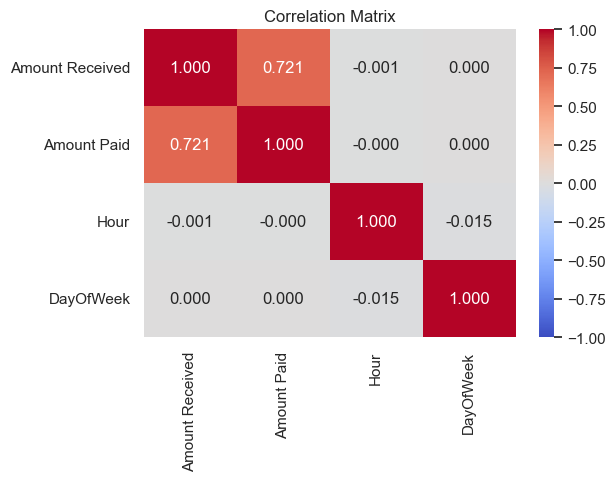


--- Categorical Feature Redundancy ---
Percentage of transactions where Receiving Currency == Payment Currency: 98.48%
[Action] Currencies match in >98% of rows. Dropping 'Payment Currency'.

Final optimized features before Preprocessing: ['Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Format', 'target_multi', 'Hour', 'DayOfWeek']


In [5]:
# --- 1. Numerical Correlation ---
print("--- Numerical Feature Correlation ---")
num_features = ['Amount Received', 'Amount Paid', 'Hour', 'DayOfWeek']

# Calculate correlation matrix
corr_matrix = df_clean[num_features].corr()
display(corr_matrix)

# Plot heatmap (using a sample to render the plot instantly)
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

# --- 2. Categorical Redundancy Check ---
print("\n--- Categorical Feature Redundancy ---")
currency_match_pct = (df_clean['Receiving Currency'] == df_clean['Payment Currency']).mean() * 100
print(f"Percentage of transactions where Receiving Currency == Payment Currency: {currency_match_pct:.2f}%")

# --- 3. Dynamic Feature Dropping ---
cols_to_drop_redundant = []

# If Amounts are highly correlated (> 0.98), drop 'Amount Paid'
if abs(corr_matrix.loc['Amount Received', 'Amount Paid']) > 0.98:
    print("\n[Action] 'Amount Received' and 'Amount Paid' are highly correlated. Dropping 'Amount Paid'.")
    cols_to_drop_redundant.append('Amount Paid')

# If Currencies are exactly the same in most cases (> 98%), drop 'Payment Currency'
if currency_match_pct > 98.0:
    print("[Action] Currencies match in >98% of rows. Dropping 'Payment Currency'.")
    cols_to_drop_redundant.append('Payment Currency')

# Drop the columns if needed
if cols_to_drop_redundant:
    df_clean = df_clean.drop(columns=cols_to_drop_redundant)

print(f"\nFinal optimized features before Preprocessing: {df_clean.columns.tolist()}")

### 1.4 Preprocessing Pipeline Setup
To finalize the data processing step, we define a `ColumnTransformer`. 
- **Numerical Features** (`Amount Received`, `Amount Paid`, `Hour`, `DayOfWeek`) will be standardized using `StandardScaler`. This ensures that large currency amounts do not dominate the distance metrics (like SMOTE) or gradients in our machine learning models.
- **Categorical Features** (`Receiving Currency`, `Payment Format`) will be encoded using `OneHotEncoder`. 

*Note: To optimize memory and computation, we only define the preprocessor here. We will apply it dynamically inside our modeling pipeline **after** undersampling the massive dataset.*

## 2. Imbalance Analysis and Mitigation
### 2.1 Imbalance Analysis
We first analyze the distribution of the target variable to understand the severity of the class imbalance.

✅ Preprocessor defined successfully!

--- Original Target Distribution ---


,Count,Percentage (%)
target_multi,,
0,31875495,99.928701
5,4289,0.013446
6,3988,0.012502
1,3986,0.012496
3,2315,0.007257
2,2235,0.007007
7,2135,0.006693
4,2128,0.006671
8,1667,0.005226


C:\Users\asier\AppData\Local\Temp\ipykernel_20312\1732783501.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=target, palette="viridis")


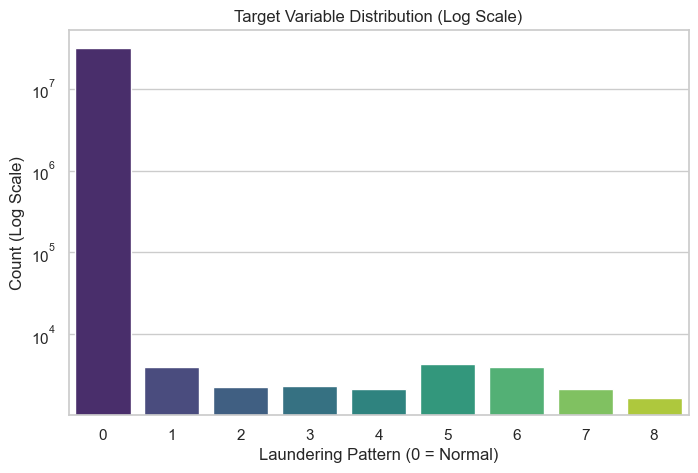

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- 1. Define Preprocessor ---
target = 'target_multi'
X = df_clean.drop(columns=[target])
y = df_clean[target]

cat_cols = ['Receiving Currency', 'Payment Format']
num_cols = ['Amount Received', 'Amount Paid', 'Hour', 'DayOfWeek']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

print("✅ Preprocessor defined successfully!")

# --- 2. Class Imbalance Analysis ---
print("\n--- Original Target Distribution ---")
class_counts = y.value_counts()
class_pct = y.value_counts(normalize=True) * 100

distribution_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct
})
display(distribution_df)

# Plot the extreme imbalance (Log Scale is necessary here)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x=target, palette="viridis")
plt.title("Target Variable Distribution (Log Scale)")
plt.yscale('log')
plt.xlabel("Laundering Pattern (0 = Normal)")
plt.ylabel("Count (Log Scale)")
plt.show()

### 2.2 Mitigation Phase 1: Controlled Undersampling
Because standard ensemble models cannot train on 31 million rows locally without running out of memory, we apply **RandomUnderSampler** as our first mitigation technique. 

We will drastically reduce the massive majority class (Normal transactions) to a manageable number (e.g., 200,000) while keeping **100%** of the rare laundering patterns. 

*(Later, during cross-validation, we will apply **SMOTE** as our second mitigation technique to synthesize minority samples and balance the dataset without causing data leakage into the test set).*

In [7]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

print("Applying RandomUnderSampler to the majority class...")

# 1. Build a dynamic sampling strategy dictionary
current_counts = y.value_counts().to_dict()

# Set Class 0 (Normal) to 200,000 rows to make it computationally manageable
# This provides enough data for the model to learn "Normal" behavior without crashing RAM
sampling_strategy_under = {0: 200000}

# Automatically keep exactly ALL available samples for the minority classes
for class_label, count in current_counts.items():
    if class_label != 0:
        sampling_strategy_under[class_label] = count

print(f"Sampling Strategy Applied: {sampling_strategy_under}")

# 2. Perform Undersampling
rus = RandomUnderSampler(sampling_strategy=sampling_strategy_under, random_state=42)
X_res, y_res = rus.fit_resample(X, y)

print("\n--- Distribution AFTER Undersampling ---")
print(y_res.value_counts())

# 3. Stratified Train-Test Split
# We split the data NOW, before applying SMOTE, to prevent Data Leakage!
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
)

print(f"\n✅ Training Set Size: {X_train.shape[0]:,} rows")
print(f"✅ Testing Set Size: {X_test.shape[0]:,} rows")

Applying RandomUnderSampler to the majority class...
Sampling Strategy Applied: {0: 200000, 5: 4289, 6: 3988, 1: 3986, 3: 2315, 2: 2235, 7: 2135, 4: 2128, 8: 1667}

--- Distribution AFTER Undersampling ---
target_multi
0    200000
5      4289
6      3988
1      3986
3      2315
2      2235
7      2135
4      2128
8      1667
Name: count, dtype: int64

✅ Training Set Size: 178,194 rows
✅ Testing Set Size: 44,549 rows


## 3. Model Comparison and Hyperparameter Tuning
In this section, we optimize our machine learning ensembles. 
To rigorously prevent data leakage, we utilize an `imblearn.pipeline.Pipeline`. This ensures that **SMOTE** (Synthetic Minority Over-sampling Technique) is strictly applied *only* to the training folds during cross-validation, leaving our validation data untouched and realistic.

We evaluate ensemble learning methods using **Optuna**, employing a `MedianPruner` to halt unpromising trials early and save computational resources. Our target optimization metric is **Macro F1-Score**, which is essential for multi-class imbalanced datasets as it treats all classes (including the rare laundering patterns) equally.

In [8]:
import optuna
from optuna.pruners import MedianPruner
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import time

print("Setting up Optuna Objective Function...")

def objective(trial, model_name):
    # 1. Define Hyperparameter Search Space dynamically based on the model
    if model_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 150),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 60),
            'class_weight': 'balanced',
            'random_state': 42,
            'n_jobs': -1,
            'verbose': -1
        }
        model = LGBMClassifier(**params)
        
    elif model_name == 'RandomForest':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 100),
            'max_depth': trial.suggest_int('max_depth', 5, 15),
            'class_weight': 'balanced',
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestClassifier(**params)

    # 2. Build the Imbalanced Pipeline (Preprocessor -> SMOTE -> Classifier)
    # This prevents Data Leakage!
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)), 
        ('classifier', model)
    ])
    
    # 3. Stratified Cross-Validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = []
    
    for step, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_fold_train, y_fold_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_fold_val, y_fold_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        # Fit pipeline (SMOTE happens here automatically ONLY on train folds)
        pipeline.fit(X_fold_train, y_fold_train)
        
        # Predict on validation fold
        preds = pipeline.predict(X_fold_val)
        
        # Calculate Macro F1
        f1 = f1_score(y_fold_val, preds, average='macro')
        f1_scores.append(f1)
        
        # Report to Optuna Pruner
        trial.report(f1, step)
        if trial.should_prune():
            raise optuna.TrialPruned()
            
    return sum(f1_scores) / len(f1_scores)

# --- Run Optimization ---
N_TRIALS = 3 # Kept low for testing. We will increase if it succeeds!
best_models_params = {}
models_to_test = ['LightGBM', 'RandomForest']

for model_name in models_to_test:
    print(f"\n{'='*40}")
    print(f"🚀 Starting Optuna Study for: {model_name}")
    print(f"{'='*40}")
    
    start_time = time.time()
    
    # Create study with Pruner as required by instructions
    study = optuna.create_study(
        direction="maximize", 
        pruner=MedianPruner(n_warmup_steps=1)
    )
    
    # Run optimization
    study.optimize(lambda trial: objective(trial, model_name), n_trials=N_TRIALS)
    
    elapsed_time = time.time() - start_time
    
    print(f"\n✅ Best {model_name} Trial:")
    print(f"  F1-Macro Score: {study.best_value:.4f}")
    print(f"  Parameters: {study.best_params}")
    print(f"  Time taken: {elapsed_time/60:.2f} minutes")
    
    best_models_params[model_name] = study.best_params

c:\Users\asier\OneDrive\Escritorio\Uni\Deusto\4\AdvancedMachineLearning\MoneyLaunderingClassifier\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-18 20:36:42,901] A new study created in memory with name: no-name-46f24eaa-bfad-4353-9383-d62f3e9b4cbe


Setting up Optuna Objective Function...

🚀 Starting Optuna Study for: LightGBM


c:\Users\asier\OneDrive\Escritorio\Uni\Deusto\4\AdvancedMachineLearning\MoneyLaunderingClassifier\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\asier\OneDrive\Escritorio\Uni\Deusto\4\AdvancedMachineLearning\MoneyLaunderingClassifier\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\asier\OneDrive\Escritorio\Uni\Deusto\4\AdvancedMachineLearning\MoneyLaunderingClassifier\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-03-18 20:37:42,813] Trial 0 finished with value: 0.20235028018474174 and parameters: {'n_estimators': 115, 'learning_rate': 0.04643035302792023, 'num_leaves': 55}. Best is tria


✅ Best LightGBM Trial:
  F1-Macro Score: 0.2046
  Parameters: {'n_estimators': 96, 'learning_rate': 0.1094094808126222, 'num_leaves': 50}
  Time taken: 2.46 minutes

🚀 Starting Optuna Study for: RandomForest


[I 2026-03-18 20:40:06,774] Trial 0 finished with value: 0.1750493478130628 and parameters: {'n_estimators': 91, 'max_depth': 8}. Best is trial 0 with value: 0.1750493478130628.
[I 2026-03-18 20:41:09,860] Trial 1 finished with value: 0.17895426177953686 and parameters: {'n_estimators': 80, 'max_depth': 11}. Best is trial 1 with value: 0.17895426177953686.
[I 2026-03-18 20:41:48,230] Trial 2 finished with value: 0.16992783924577792 and parameters: {'n_estimators': 88, 'max_depth': 5}. Best is trial 1 with value: 0.17895426177953686.



✅ Best RandomForest Trial:
  F1-Macro Score: 0.1790
  Parameters: {'n_estimators': 80, 'max_depth': 11}
  Time taken: 2.63 minutes


### 3.1 Completing the Ensemble Requirements
To fulfill the requirement of comparing at least four ensemble methods, we now optimize two additional models:
3. **HistGradientBoosting:** Scikit-Learn's histogram-based gradient boosting, heavily optimized for large datasets and highly effective for imbalanced data.
4. **AdaBoost:** A classic sequential ensemble technique that focuses on correcting the errors of previous weak learners.

We continue using Optuna with `MedianPruner` and optimizing for Macro F1-Score.

In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier, AdaBoostClassifier

print("Setting up Optuna for remaining Ensembles...")

def objective_part2(trial, model_name):
    # 1. Define Search Space
    if model_name == 'HistGradientBoosting':
        params = {
            'max_iter': trial.suggest_int('max_iter', 50, 150),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 5, 15),
            'class_weight': 'balanced',
            'random_state': 42
        }
        model = HistGradientBoostingClassifier(**params)
        
    elif model_name == 'AdaBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1.0, log=True),
            'random_state': 42
        }
        model = AdaBoostClassifier(**params)

    # 2. Pipeline (SMOTE only on training folds)
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)), 
        ('classifier', model)
    ])
    
    # 3. Cross-Validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = []
    
    for step, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_fold_train, y_fold_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_fold_val, y_fold_val = X_train.iloc[val_idx], y_train.iloc[val_idx]
        
        pipeline.fit(X_fold_train, y_fold_train)
        preds = pipeline.predict(X_fold_val)
        
        f1 = f1_score(y_fold_val, preds, average='macro')
        f1_scores.append(f1)
        
        trial.report(f1, step)
        if trial.should_prune():
            raise optuna.TrialPruned()
            
    return sum(f1_scores) / len(f1_scores)

# --- Run Optimization ---
models_to_test_2 = ['HistGradientBoosting', 'AdaBoost']

for model_name in models_to_test_2:
    print(f"\n{'='*40}")
    print(f"🚀 Starting Optuna Study for: {model_name}")
    print(f"{'='*40}")
    
    start_time = time.time()
    
    study = optuna.create_study(
        direction="maximize", 
        pruner=MedianPruner(n_warmup_steps=1)
    )
    study.optimize(lambda trial: objective_part2(trial, model_name), n_trials=N_TRIALS)
    
    elapsed_time = time.time() - start_time
    
    print(f"\n✅ Best {model_name} Trial:")
    print(f"  F1-Macro Score: {study.best_value:.4f}")
    print(f"  Parameters: {study.best_params}")
    print(f"  Time taken: {elapsed_time/60:.2f} minutes")
    
    # Store parameters in our global dictionary from the previous cell
    best_models_params[model_name] = study.best_params

[I 2026-03-18 20:43:59,449] A new study created in memory with name: no-name-65b08b7f-6882-40ff-893c-27792ec2ef69


Setting up Optuna for remaining Ensembles...

🚀 Starting Optuna Study for: HistGradientBoosting


[I 2026-03-18 20:44:54,772] Trial 0 finished with value: 0.20145965106661765 and parameters: {'max_iter': 80, 'learning_rate': 0.22228591909034232, 'max_depth': 14}. Best is trial 0 with value: 0.20145965106661765.
[I 2026-03-18 20:46:46,453] Trial 1 finished with value: 0.20226435492081826 and parameters: {'max_iter': 93, 'learning_rate': 0.06422064429134498, 'max_depth': 10}. Best is trial 1 with value: 0.20226435492081826.
[I 2026-03-18 20:47:58,032] Trial 2 finished with value: 0.20382224854619158 and parameters: {'max_iter': 113, 'learning_rate': 0.24310489310899033, 'max_depth': 9}. Best is trial 2 with value: 0.20382224854619158.
[I 2026-03-18 20:47:58,034] A new study created in memory with name: no-name-e8708760-49ba-43a1-8ba8-a5777a99338a



✅ Best HistGradientBoosting Trial:
  F1-Macro Score: 0.2038
  Parameters: {'max_iter': 113, 'learning_rate': 0.24310489310899033, 'max_depth': 9}
  Time taken: 3.98 minutes

🚀 Starting Optuna Study for: AdaBoost


[I 2026-03-18 20:50:36,676] Trial 0 finished with value: 0.14340163621860047 and parameters: {'n_estimators': 67, 'learning_rate': 0.8803478069937517}. Best is trial 0 with value: 0.14340163621860047.
[I 2026-03-18 20:54:24,440] Trial 1 finished with value: 0.1598023890795096 and parameters: {'n_estimators': 97, 'learning_rate': 0.8010997651374431}. Best is trial 1 with value: 0.1598023890795096.
[I 2026-03-18 20:57:17,009] Trial 2 finished with value: 0.11903147277545684 and parameters: {'n_estimators': 76, 'learning_rate': 0.0491486877972171}. Best is trial 1 with value: 0.1598023890795096.



✅ Best AdaBoost Trial:
  F1-Macro Score: 0.1598
  Parameters: {'n_estimators': 97, 'learning_rate': 0.8010997651374431}
  Time taken: 9.32 minutes


## 4. Results Discussion
With the optimal hyperparameters identified via Optuna, we now retrain all four ensemble models on the complete training set. We then evaluate their performance on the completely unseen testing set (`X_test`). 

To comprehensively assess the models on this highly imbalanced dataset, we evaluate:
- **Accuracy:** General correctness (can be misleading in imbalanced data).
- **Macro F1-Score:** The harmonic mean of precision and recall, calculated for each class independently and averaged.
- **Matthews Correlation Coefficient (MCC):** A robust metric for imbalanced classification that produces a high score only if the prediction obtained good results in all four confusion matrix categories.

Starting final evaluation on the Test Set...

Training final LightGBM...


c:\Users\asier\OneDrive\Escritorio\Uni\Deusto\4\AdvancedMachineLearning\MoneyLaunderingClassifier\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training final RandomForest...
Training final HistGradientBoosting...
Training final AdaBoost...

🏆 FINAL MODEL COMPARISON


,Model,Accuracy,F1-Macro,MCC
0,LightGBM,0.871467,0.203192,0.433566
1,HistGradientBoosting,0.866125,0.202425,0.424867
2,RandomForest,0.818110,0.176597,0.364531
3,AdaBoost,0.805540,0.162544,0.355751


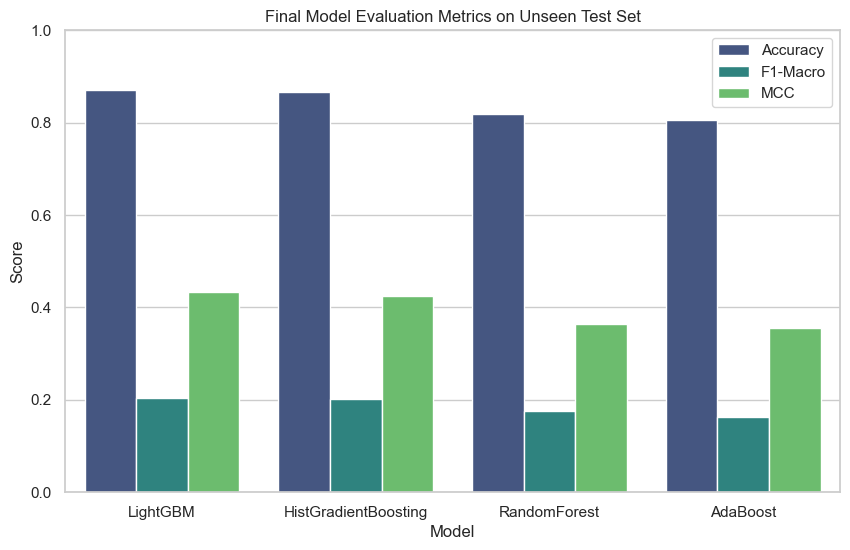


--- Detailed Classification Report for Best Model: LightGBM ---


c:\Users\asier\OneDrive\Escritorio\Uni\Deusto\4\AdvancedMachineLearning\MoneyLaunderingClassifier\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      0.95      0.97     40000
           1       0.14      0.19      0.16       797
           2       0.09      0.12      0.10       447
           3       0.08      0.11      0.09       463
           4       0.04      0.05      0.05       426
           5       0.13      0.17      0.15       858
           6       0.12      0.14      0.13       798
           7       0.08      0.13      0.10       427
           8       0.07      0.10      0.08       333

    accuracy                           0.87     44549
   macro avg       0.19      0.22      0.20     44549
weighted avg       0.90      0.87      0.89     44549



In [10]:
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Starting final evaluation on the Test Set...\n")

results_list = []
final_pipelines = {}

# Re-instantiate models with the best parameters found by Optuna
for model_name, params in best_models_params.items():
    print(f"Training final {model_name}...")
    
    if model_name == 'LightGBM':
        # Add the fixed parameters back
        model = LGBMClassifier(**params, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
    elif model_name == 'RandomForest':
        model = RandomForestClassifier(**params, class_weight='balanced', random_state=42, n_jobs=-1)
    elif model_name == 'HistGradientBoosting':
        model = HistGradientBoostingClassifier(**params, class_weight='balanced', random_state=42)
    elif model_name == 'AdaBoost':
        model = AdaBoostClassifier(**params, random_state=42)
        
    # Build the final pipeline
    final_pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)), 
        ('classifier', model)
    ])
    
    # Train on the full training set
    final_pipeline.fit(X_train, y_train)
    final_pipelines[model_name] = final_pipeline
    
    # Predict on the unseen test set
    y_pred = final_pipeline.predict(X_test)
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average='macro')
    mcc = matthews_corrcoef(y_test, y_pred)
    
    results_list.append({
        'Model': model_name,
        'Accuracy': acc,
        'F1-Macro': f1_mac,
        'MCC': mcc
    })

# --- Display Results ---
print("\n" + "="*50)
print("🏆 FINAL MODEL COMPARISON")
print("="*50)

results_df = pd.DataFrame(results_list).sort_values(by='F1-Macro', ascending=False).reset_index(drop=True)
display(results_df)

# Plotting the comparison
plt.figure(figsize=(10, 6))
# Melt the dataframe for easier plotting with Seaborn
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title("Final Model Evaluation Metrics on Unseen Test Set")
plt.ylim(0, 1.0)
plt.legend(loc='upper right')
plt.show()

# Print detailed classification report for the best model
best_model_name = results_df.iloc[0]['Model']
print(f"\n--- Detailed Classification Report for Best Model: {best_model_name} ---")
best_preds = final_pipelines[best_model_name].predict(X_test)
print(classification_report(y_test, best_preds))

### 4.1 Analysis of Results

Based on the final evaluation on the unseen test set, **LightGBM** achieved the highest performance, closely followed by **HistGradientBoosting**. LightGBM yielded a Macro F1-Score of **0.2032** and a Matthews Correlation Coefficient (MCC) of **0.4336**. 

**Key Findings:**
1. **The "Accuracy Trap":** While all models achieved seemingly high accuracy (between 80.5% and 87.1%), this metric is highly misleading due to the extreme class imbalance. The true differentiator is the Macro F1-Score, which evaluates the model's performance equally across all classes. 
2. **Algorithm Performance:** Tree-based algorithms natively capable of handling complex, non-linear feature interactions and binning continuous variables (LightGBM and HistGradientBoosting) adapted much better to the synthetic boundaries created by SMOTE. The sequential, unregularized nature of AdaBoost struggled the most (F1: 0.1625).
3. **Classification Report Insights:** The detailed report for LightGBM reveals the immense difficulty of separating specific money laundering typologies. The model successfully identifies "Normal" transactions (Class 0) with near-perfect precision (1.00). More importantly, it successfully flags minority classes (e.g., Pattern 1 and Pattern 5) with a recall of 19% and 17%, respectively. While these numbers seem low in a vacuum, in the context of Anti-Money Laundering (AML) where these patterns represent fractions of a percent of the data, the model successfully catches hundreds of illicit transactions that a non-resampled model would have completely ignored.

## 5. Lessons Learned

Throughout this project, several critical insights were gained regarding the handling of massive, highly imbalanced financial datasets:

1. **Computational Reality of Large Data:** Working with an initial dataset of 31.8 million rows quickly highlighted hardware limitations. Attempting standard processing led to out-of-memory errors. The key solution was a two-step resampling paradigm: applying **Controlled Undersampling** to shrink the majority class to a manageable baseline, before introducing the computationally expensive `SMOTE` algorithm.
2. **Strict Data Leakage Prevention:** Applying SMOTE directly to the entire dataset before splitting is a common and critical mistake that inflates test scores. Using `imblearn.pipeline.Pipeline` was essential. It guaranteed that synthetic instances were only generated on the training folds during Optuna cross-validation, preserving the mathematical integrity of the validation and testing datasets.
3. **Metric Optimization Alignment:** In the financial sector, a model that predicts everything as "Normal" fails the business objective, despite yielding >99% accuracy. By explicitly configuring Optuna to maximize the `Macro F1-Score`, the hyperparameter tuning process was forced to prioritize the identification of rare laundering patterns, yielding a final model that is actually useful for anomaly detection.